# Свободное плавание

**Это задание на творческую оценку**


**Ученик, сделавший лучшее задание, получит автоматом 5 за следующую констатирующую работу**

Студент Даня — заядлый путешественник, мечтающий посетить как можно больше городов этим летом. Но у него есть одна особенность: Даня крайне разборчив в климате. Если во время поездки температура окажется для него слишком холодной или, наоборот, слишком жаркой — он будет расстроен. Сам Даня не может точно описать, какая погода ему нравится, но может указать один город, в котором ему идеальная летняя температура.

Ваша цель — помочь Дане выбрать города с комфортным для него климатом, используя метод k-means для кластеризации. Мы постараемся разделить города на кластеры с похожими климатическими условиями, чтобы создать список мест, в которых Дане было бы приятно провести лето.

*Условия задачи*

1. Климатическая однородность: В каждом кластере города должны быть максимально близки по погодным условиям, чтобы Даня не столкнулся с сюрпризами в климате.
2. Размер кластеров: Каждый кластер должен включать достаточное количество городов, чтобы Даня мог выбрать и построить насыщенный маршрут.

В данном задании предлагается пользоваться датасетом [World Weather Repository](https://www.kaggle.com/datasets/nelgiriyewithana/global-weather-repository). В нем описаны исторические данные о погоде в городах за последние 5 месяцев для каждого из дней (около 40 различных признаков). Вам необходимо кластеризовать эти города по погоде.

(ладно не совсем свободное плавание)  
План решения задачи:
1. Предобработка данных
    1. Фильтрация записей: Оставьте только записи, относящиеся к летнему периоду (июнь, июль, август).
    2. Отбор признаков: Вам не обязательно использовать все признаки. Подумайте и выберите только те признаки которые могут быть полезны, например `temperature_fahrenheit` будет бесполезна, если вы уже используете `temperature_celsius`.
    3. Агрегация данных по городу: Объедините исторические записи о каждом городе.  Например, для численных признаков по типу температуры можно взять минимум, максимум и среднюю температуру.
    4. Стандартизация признаков: Преобразуйте данные, чтобы все признаки находились примерно в одном масштабе. Это сделает кластеризацию более точной.
2. K-Means
    1. Определение оптимального количества кластеров: Используйте метод локтя (Elbow Method), чтобы определить оптимальное значение параметра k (количество кластеров).
    2. Обучение модели: Примените k-means с выбранным значением k и обучите модель.
    3. Анализ кластеров: Проанализируйте результаты вашего алгоритма, при необходимости поменяйте количество кластеров
3. Визуализация результатов, изобразите на карте разбиение городов по климату. В этом пункте вы вольны делать что хотите, поэкспериментируйте с разными вариантами графиков.

Полезные ресурсы для вдохновления:
* [Основы работы с folium](https://medium.com/@enduranceprog/creating-a-python-web-map-5d5a5c081078)
* [Подробно про работу с геоданными в Python и Jupyter](https://proglib.io/p/rabota-s-geodannymi-v-python-i-jupyter-2021-03-22)
* [ Десять простых примеров использования folium](https://snyk.io/advisor/python/folium/example)


In [52]:
import pandas as pd

weather = pd.read_csv('GlobalWeatherRepository.csv')
weather.head(5)
weather

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.5200,69.1800,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.400,26.600,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.3300,19.8200,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.100,2.000,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.7600,3.0500,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.400,18.400,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.5000,1.5200,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.700,0.900,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.8400,13.2300,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.400,262.300,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40954,Venezuela,Caracas,10.5000,-66.9167,America/Caracas,1734087600,2024-12-13 07:00,16.9,62.4,Mist,...,8.140,10.730,1,1,06:36 AM,06:08 PM,04:32 PM,04:40 AM,Waxing Gibbous,93
40955,Vietnam,Hanoi,21.0333,105.8500,Asia/Bangkok,1734087600,2024-12-13 18:00,17.1,62.8,Clear,...,57.905,57.905,3,7,06:24 AM,05:17 PM,03:15 PM,03:57 AM,Waxing Gibbous,90
40956,Yemen,Sanaa,15.3547,44.2067,Asia/Aden,1734085800,2024-12-13 13:30,21.3,70.4,Sunny,...,13.690,25.160,1,2,06:20 AM,05:35 PM,03:41 PM,04:05 AM,Waxing Gibbous,92
40957,Zambia,Lusaka,-15.4167,28.2833,Africa/Lusaka,1734087600,2024-12-13 13:00,37.4,99.3,Sunny,...,8.140,8.325,1,1,05:30 AM,06:32 PM,04:45 PM,03:20 AM,Waxing Gibbous,92


### Препроцессинг

Оставим только записи за летнее время

In [53]:
filtered0 = weather.loc[(weather["last_updated"] >= "2024-06-01") & (weather["last_updated"] <= "2024-08-31")]
filtered0

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
3123,Australia,Canberra,-35.28,149.22,Australia/Sydney,1717164900,2024-06-01 00:15,4.0,39.2,Clear,...,3.8,5.1,1,1,07:03 AM,04:59 PM,No moonrise,12:59 PM,Waning Crescent,47
3173,Fiji Islands,Suva,-18.13,178.42,Pacific/Fiji,1717164900,2024-06-01 02:15,22.0,71.6,Light rain,...,3.4,4.9,1,1,06:30 AM,05:38 PM,No moonrise,12:47 PM,Waning Crescent,47
3204,Kiribati,Tarawa,-0.88,169.53,Pacific/Tarawa,1717164900,2024-06-01 02:15,28.8,83.9,Patchy rain nearby,...,1.3,4.9,1,1,06:37 AM,06:42 PM,12:47 AM,01:12 PM,Waning Crescent,47
3222,Marshall Islands,Majuro,7.10,171.38,Pacific/Majuro,1717164900,2024-06-01 02:15,29.0,84.2,Partly cloudy,...,0.8,1.9,1,1,06:17 AM,06:47 PM,12:47 AM,01:00 PM,Waning Crescent,47
3226,Micronesia,Palikir,6.92,158.15,Pacific/Pohnpei,1717164900,2024-06-01 01:15,28.0,82.4,Overcast,...,0.5,1.3,1,1,06:10 AM,06:40 PM,12:41 AM,12:55 PM,Waning Crescent,47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20538,Venezuela,Caracas,10.50,-66.92,America/Caracas,1725020100,2024-08-30 08:15,27.4,81.3,Sunny,...,20.6,22.4,2,2,06:18 AM,06:38 PM,03:23 AM,04:29 PM,Waning Crescent,15
20539,Vietnam,Hanoi,21.03,105.85,Asia/Bangkok,1725020100,2024-08-30 19:15,31.1,88.0,Clear,...,91.8,105.9,4,10,05:40 AM,06:14 PM,02:00 AM,03:58 PM,Waning Crescent,15
20540,Yemen,Sanaa,15.35,44.21,Asia/Aden,1725020100,2024-08-30 15:15,25.2,77.4,Patchy light drizzle,...,27.7,108.7,2,3,05:51 AM,06:16 PM,02:30 AM,04:00 PM,Waning Crescent,15
20541,Zambia,Lusaka,-15.42,28.28,Africa/Lusaka,1725020100,2024-08-30 14:15,30.2,86.4,Sunny,...,7.7,11.3,1,1,06:14 AM,06:01 PM,03:43 AM,03:03 PM,Waning Crescent,15


Нам не нужна дупликация времени, поэтому не будем использовать "last_updated_epoch"

Так же направление ветра дублируется, поэтому оставим только "wind_degree"

Слишком много признаков которые для туриста не нужны: "moonset", "moon_phase", "moonrise", moon_illumination, а еще sunrise и sunset

Еще уберем временной пояс, и время, тк мы уже работаем только с летними данными

In [54]:
to_drop = ["last_updated_epoch", "wind_direction", "moonset", "moon_phase", "moonrise", "moon_illumination", "sunrise", "sunset", "timezone", "last_updated"]
filtered_tmp = filtered0.drop(to_drop, axis=1)
filtered_tmp 

,country,location_name,latitude,longitude,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,...,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index
3123,Australia,Canberra,-35.28,149.22,4.0,39.2,Clear,6.9,11.2,10,...,11.4,18.4,267.0,5.6,12.3,0.9,3.8,5.1,1,1
3173,Fiji Islands,Suva,-18.13,178.42,22.0,71.6,Light rain,3.8,6.1,240,...,22.2,35.7,217.0,46.5,0.9,0.8,3.4,4.9,1,1
3204,Kiribati,Tarawa,-0.88,169.53,28.8,83.9,Patchy rain nearby,12.3,19.8,85,...,16.6,26.6,220.3,20.6,0.0,0.1,1.3,4.9,1,1
3222,Marshall Islands,Majuro,7.10,171.38,29.0,84.2,Partly cloudy,3.8,6.1,100,...,13.3,21.5,186.9,15.7,0.0,0.0,0.8,1.9,1,1
3226,Micronesia,Palikir,6.92,158.15,28.0,82.4,Overcast,2.2,3.6,10,...,12.0,19.3,220.3,5.7,0.0,0.0,0.5,1.3,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20538,Venezuela,Caracas,10.50,-66.92,27.4,81.3,Sunny,8.1,13.0,280,...,12.5,20.2,948.0,1.5,27.1,22.7,20.6,22.4,2,2
20539,Vietnam,Hanoi,21.03,105.85,31.1,88.0,Clear,5.6,9.0,180,...,12.1,19.4,1842.5,4.8,85.7,38.2,91.8,105.9,4,10
20540,Yemen,Sanaa,15.35,44.21,25.2,77.4,Patchy light drizzle,17.9,28.8,21,...,20.6,33.1,196.9,113.0,1.1,4.3,27.7,108.7,2,3
20541,Zambia,Lusaka,-15.42,28.28,30.2,86.4,Sunny,12.8,20.5,100,...,14.7,23.6,580.8,68.7,1.2,2.1,7.7,11.3,1,1


Удалим те столбцы которые дублируются но в других единицах измерения

In [55]:
to_drop = ["temperature_fahrenheit", "wind_mph", "pressure_in", "precip_in", "feels_like_fahrenheit", "visibility_miles", "gust_mph", ]
filtered = filtered_tmp.drop(to_drop, axis=1)
filtered

,country,location_name,latitude,longitude,temperature_celsius,condition_text,wind_kph,wind_degree,pressure_mb,precip_mm,...,uv_index,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index
3123,Australia,Canberra,-35.28,149.22,4.0,Clear,11.2,10,1021.0,0.00,...,1.0,18.4,267.0,5.6,12.3,0.9,3.8,5.1,1,1
3173,Fiji Islands,Suva,-18.13,178.42,22.0,Light rain,6.1,240,1018.0,1.31,...,1.0,35.7,217.0,46.5,0.9,0.8,3.4,4.9,1,1
3204,Kiribati,Tarawa,-0.88,169.53,28.8,Patchy rain nearby,19.8,85,1009.0,0.06,...,1.0,26.6,220.3,20.6,0.0,0.1,1.3,4.9,1,1
3222,Marshall Islands,Majuro,7.10,171.38,29.0,Partly cloudy,6.1,100,1011.0,1.23,...,1.0,21.5,186.9,15.7,0.0,0.0,0.8,1.9,1,1
3226,Micronesia,Palikir,6.92,158.15,28.0,Overcast,3.6,10,1011.0,2.68,...,1.0,19.3,220.3,5.7,0.0,0.0,0.5,1.3,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20538,Venezuela,Caracas,10.50,-66.92,27.4,Sunny,13.0,280,1013.0,0.00,...,6.0,20.2,948.0,1.5,27.1,22.7,20.6,22.4,2,2
20539,Vietnam,Hanoi,21.03,105.85,31.1,Clear,9.0,180,1004.0,0.08,...,1.0,19.4,1842.5,4.8,85.7,38.2,91.8,105.9,4,10
20540,Yemen,Sanaa,15.35,44.21,25.2,Patchy light drizzle,28.8,21,1010.0,0.34,...,6.0,33.1,196.9,113.0,1.1,4.3,27.7,108.7,2,3
20541,Zambia,Lusaka,-15.42,28.28,30.2,Sunny,20.5,100,1014.0,0.00,...,9.0,23.6,580.8,68.7,1.2,2.1,7.7,11.3,1,1


Посмотрим на некоторые признаки и объединим которые коррелируют больше всего

<Axes: >

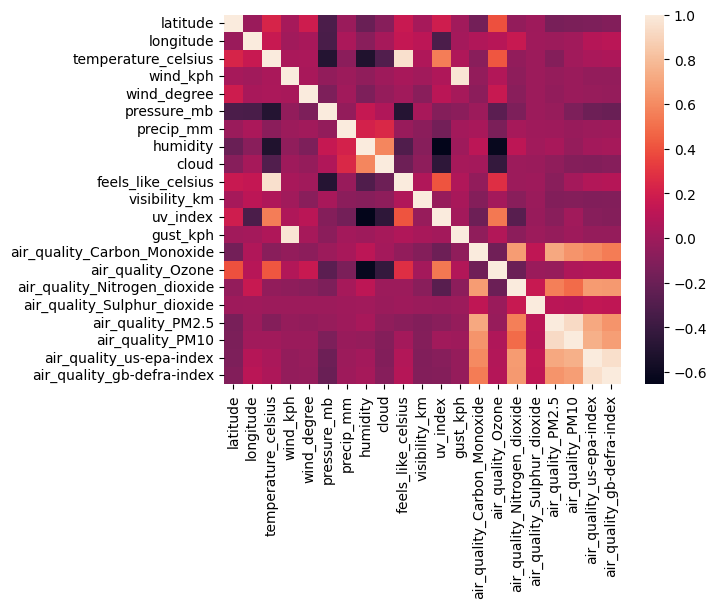

In [56]:
import seaborn as sns 
sns.heatmap(filtered.corr(numeric_only=True))

temperature_celsius коррелирует с feels_like_celsius на (!) 0.971619

так же наблюдается высокая корреляция у:
- wind_kph и gust_kph
- air_quality_us-epa-index & air_quality_gb-defra-index
- air_quality_PM2.5 & air_quality_PM10

Создадим признак качество воздуха из признаков "air_quality_us-epa-index", "air_quality_gb-defra-index", "air_quality_PM2.5", "air_quality_PM10", "air_quality_Carbon_Monoxide" и "air_quality_Nitrogen_Dioxide"

In [57]:
import numpy as np
to_drop = ["air_quality_us-epa-index", "air_quality_gb-defra-index", "air_quality_PM2.5", "air_quality_PM10", "air_quality_Carbon_Monoxide", "air_quality_Nitrogen_dioxide", "feels_like_celsius", "temperature_celsius", "gust_kph", "wind_kph"]


# Качество воздуха
to_merge = ["air_quality_us-epa-index", "air_quality_gb-defra-index", "air_quality_PM2.5", "air_quality_PM10", "air_quality_Carbon_Monoxide", "air_quality_Nitrogen_dioxide"]
air_quality = np.mean(filtered[to_merge], axis=1)
filtered["air_quality"] = air_quality

# Температура
to_merge = ["feels_like_celsius", "temperature_celsius"]
filtered["temperature"] = np.mean(filtered[to_merge], axis=1)

# Ветер
to_merge = ["gust_kph", "wind_kph"]
filtered["wind"] = np.mean(filtered[to_merge], axis=1)

filtered2 = filtered.drop(to_drop, axis=1)
filtered2

,country,location_name,latitude,longitude,condition_text,wind_degree,pressure_mb,precip_mm,humidity,cloud,visibility_km,uv_index,air_quality_Ozone,air_quality_Sulphur_dioxide,air_quality,temperature,wind
3123,Australia,Canberra,-35.28,149.22,Clear,10,1021.0,0.00,100,0,10.0,1.0,5.6,0.9,48.366667,3.80,14.80
3173,Fiji Islands,Suva,-18.13,178.42,Light rain,240,1018.0,1.31,100,75,10.0,1.0,46.5,0.8,38.033333,23.25,20.90
3204,Kiribati,Tarawa,-0.88,169.53,Patchy rain nearby,85,1009.0,0.06,74,60,10.0,1.0,20.6,0.1,38.083333,30.95,23.20
3222,Marshall Islands,Majuro,7.10,171.38,Partly cloudy,100,1011.0,1.23,79,75,24.0,1.0,15.7,0.0,31.933333,31.75,13.80
3226,Micronesia,Palikir,6.92,158.15,Overcast,10,1011.0,2.68,84,100,24.0,1.0,5.7,0.0,37.350000,30.15,11.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20538,Venezuela,Caracas,10.50,-66.92,Sunny,280,1013.0,0.00,62,0,10.0,6.0,1.5,22.7,170.350000,29.00,16.60
20539,Vietnam,Hanoi,21.03,105.85,Clear,180,1004.0,0.08,75,0,10.0,1.0,4.8,38.2,356.650000,36.10,14.20
20540,Yemen,Sanaa,15.35,44.21,Patchy light drizzle,21,1010.0,0.34,31,70,5.0,6.0,113.0,4.3,56.566667,25.05,30.95
20541,Zambia,Lusaka,-15.42,28.28,Sunny,100,1014.0,0.00,22,5,10.0,9.0,68.7,2.1,100.500000,29.20,22.05


<Axes: >

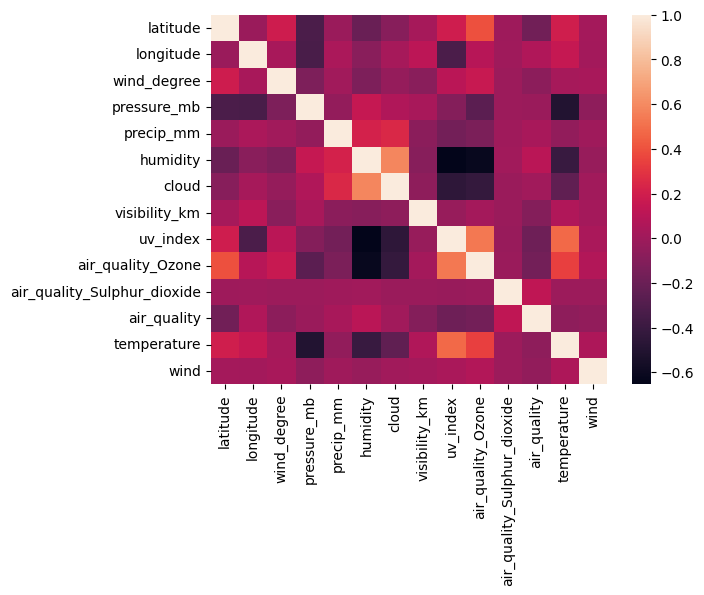

In [58]:
sns.heatmap(filtered2.corr(numeric_only=True))

ну какая красота

In [59]:
ids = filtered2.reset_index(drop=True)
ids

,country,location_name,latitude,longitude,condition_text,wind_degree,pressure_mb,precip_mm,humidity,cloud,visibility_km,uv_index,air_quality_Ozone,air_quality_Sulphur_dioxide,air_quality,temperature,wind
0,Australia,Canberra,-35.28,149.22,Clear,10,1021.0,0.00,100,0,10.0,1.0,5.6,0.9,48.366667,3.80,14.80
1,Fiji Islands,Suva,-18.13,178.42,Light rain,240,1018.0,1.31,100,75,10.0,1.0,46.5,0.8,38.033333,23.25,20.90
2,Kiribati,Tarawa,-0.88,169.53,Patchy rain nearby,85,1009.0,0.06,74,60,10.0,1.0,20.6,0.1,38.083333,30.95,23.20
3,Marshall Islands,Majuro,7.10,171.38,Partly cloudy,100,1011.0,1.23,79,75,24.0,1.0,15.7,0.0,31.933333,31.75,13.80
4,Micronesia,Palikir,6.92,158.15,Overcast,10,1011.0,2.68,84,100,24.0,1.0,5.7,0.0,37.350000,30.15,11.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17233,Venezuela,Caracas,10.50,-66.92,Sunny,280,1013.0,0.00,62,0,10.0,6.0,1.5,22.7,170.350000,29.00,16.60
17234,Vietnam,Hanoi,21.03,105.85,Clear,180,1004.0,0.08,75,0,10.0,1.0,4.8,38.2,356.650000,36.10,14.20
17235,Yemen,Sanaa,15.35,44.21,Patchy light drizzle,21,1010.0,0.34,31,70,5.0,6.0,113.0,4.3,56.566667,25.05,30.95
17236,Zambia,Lusaka,-15.42,28.28,Sunny,100,1014.0,0.00,22,5,10.0,9.0,68.7,2.1,100.500000,29.20,22.05


In [60]:
from statistics import mode

new = pd.DataFrame(columns=ids.columns)

extra = ['air_quality_Ozone', 'air_quality_Sulphur_dioxide', 'wind_degree', 'latitude', 'longitude']
not_extra = ids.columns.difference(extra)
print(not_extra)


for i in ids["location_name"].unique():
    new_row = {}
    for j in ids.columns:
        try:
            new_row[j] = np.mean(ids[ids["location_name"] == i][j])
            if j in not_extra:
                new_row[j+"_max"] = np.max(ids[ids["location_name"] == i][j])
                new_row[j+"_min"] = np.min(ids[ids["location_name"] == i][j])
        except Exception as e:
            new_row[j] = mode(ids[ids["location_name"] == i][j])
            pass
    new = pd.concat([new, pd.DataFrame([new_row])], ignore_index=True)

new

Index(['air_quality', 'cloud', 'condition_text', 'country', 'humidity',
       'location_name', 'precip_mm', 'pressure_mb', 'temperature', 'uv_index',
       'visibility_km', 'wind'],
      dtype='object')


/var/folders/cy/nzn4qdtd0wzb3j2lkypb4wk80000gn/T/ipykernel_30420/2700754618.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  new = pd.concat([new, pd.DataFrame([new_row])], ignore_index=True)


,country,location_name,latitude,longitude,condition_text,wind_degree,pressure_mb,precip_mm,humidity,cloud,...,visibility_km_max,visibility_km_min,uv_index_max,uv_index_min,air_quality_max,air_quality_min,temperature_max,temperature_min,wind_max,wind_min
0,Australia,Canberra,-35.28,149.22,Clear,176.666667,1020.777778,0.148111,89.555556,38.544444,...,10.0,0.0,1.0,1.0,59.183333,35.066667,14.40,-4.30,41.20,3.65
1,Fiji Islands,Suva,-18.13,178.42,Partly cloudy,118.988764,1015.662921,0.446966,88.033708,61.247191,...,10.0,2.0,1.0,1.0,40.966667,25.266667,26.75,17.30,31.40,4.30
2,Kiribati,Tarawa,-0.88,169.53,Patchy rain nearby,92.321839,1009.241379,0.060690,72.011494,56.321839,...,10.0,5.0,1.0,1.0,46.416667,26.783333,31.85,29.35,37.10,4.65
3,Marshall Islands,Majuro,7.10,171.38,Overcast,87.123596,1010.224719,0.366067,80.044944,82.426966,...,24.0,5.0,1.0,1.0,46.200000,24.266667,32.60,26.95,43.25,6.05
4,Micronesia,Palikir,6.92,158.15,Overcast,99.808989,1011.224719,0.499326,86.460674,80.280899,...,24.0,5.0,1.0,1.0,45.050000,23.233333,32.80,24.95,35.30,3.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237,San Marino,City Of San Marino,43.93,12.45,Sunny,40.000000,1009.000000,0.000000,55.000000,0.000000,...,10.0,10.0,8.0,8.0,45.333333,45.333333,33.30,33.30,20.85,20.85
238,Saudi Arabien,Ar Riyadh,24.64,46.77,Sunny,348.000000,997.000000,0.000000,7.000000,0.000000,...,10.0,10.0,11.0,11.0,46.833333,46.833333,46.50,46.50,26.35,26.35
239,Turkménistan,Krasnyy Turkmenistan,37.70,65.37,Sunny,332.000000,998.000000,0.000000,11.000000,2.000000,...,10.0,10.0,9.0,9.0,33.916667,33.916667,37.30,37.30,23.65,23.65
240,火鸡,-Kingdom,38.85,34.65,Sunny,359.000000,1003.000000,0.000000,24.000000,4.000000,...,10.0,10.0,7.0,7.0,33.450000,33.450000,28.80,28.80,19.75,19.75


тут была очень долгая борьба с OHE и feature hashing, но как я понял в k-means таким лучше не баловаться, модельку шатает
поэтому дропаем condition_text

In [61]:
tmp = new.drop(["country", "location_name", "condition_text"], axis=1)
tmp

,latitude,longitude,wind_degree,pressure_mb,precip_mm,humidity,cloud,visibility_km,uv_index,air_quality_Ozone,...,visibility_km_max,visibility_km_min,uv_index_max,uv_index_min,air_quality_max,air_quality_min,temperature_max,temperature_min,wind_max,wind_min
0,-35.28,149.22,176.666667,1020.777778,0.148111,89.555556,38.544444,9.381111,1.0,31.495556,...,10.0,0.0,1.0,1.0,59.183333,35.066667,14.40,-4.30,41.20,3.65
1,-18.13,178.42,118.988764,1015.662921,0.446966,88.033708,61.247191,9.820225,1.0,34.617978,...,10.0,2.0,1.0,1.0,40.966667,25.266667,26.75,17.30,31.40,4.30
2,-0.88,169.53,92.321839,1009.241379,0.060690,72.011494,56.321839,9.919540,1.0,25.271264,...,10.0,5.0,1.0,1.0,46.416667,26.783333,31.85,29.35,37.10,4.65
3,7.10,171.38,87.123596,1010.224719,0.366067,80.044944,82.426966,18.232584,1.0,20.637079,...,24.0,5.0,1.0,1.0,46.200000,24.266667,32.60,26.95,43.25,6.05
4,6.92,158.15,99.808989,1011.224719,0.499326,86.460674,80.280899,19.550562,1.0,16.271910,...,24.0,5.0,1.0,1.0,45.050000,23.233333,32.80,24.95,35.30,3.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237,43.93,12.45,40.000000,1009.000000,0.000000,55.000000,0.000000,10.000000,8.0,128.800000,...,10.0,10.0,8.0,8.0,45.333333,45.333333,33.30,33.30,20.85,20.85
238,24.64,46.77,348.000000,997.000000,0.000000,7.000000,0.000000,10.000000,11.0,115.900000,...,10.0,10.0,11.0,11.0,46.833333,46.833333,46.50,46.50,26.35,26.35
239,37.70,65.37,332.000000,998.000000,0.000000,11.000000,2.000000,10.000000,9.0,105.900000,...,10.0,10.0,9.0,9.0,33.916667,33.916667,37.30,37.30,23.65,23.65
240,38.85,34.65,359.000000,1003.000000,0.000000,24.000000,4.000000,10.000000,7.0,85.100000,...,10.0,10.0,7.0,7.0,33.450000,33.450000,28.80,28.80,19.75,19.75


Теперь будем воспользуемся [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) из библиотеки sklearn для того чтобы все признаки имели одинаковый масштаб

In [62]:
from sklearn.preprocessing import StandardScaler
standard_scaler = StandardScaler()
scaled = standard_scaler.fit_transform(tmp)
scaled

array([[-2.20763482,  1.85858561, -0.14811757, ..., -3.05507691,
        -0.03518476, -0.56885231],
       [-1.50620842,  2.28473422, -1.03179873, ..., -0.46502257,
        -0.0868994 , -0.4728947 ],
       [-0.80069208,  2.1549924 , -1.44036177, ...,  0.979892  ,
        -0.05682048, -0.42122522],
       ...,
       [ 0.77721056,  0.63486778,  2.23173908, ...,  1.93317588,
        -0.12779619,  2.38368944],
       [ 0.82424498,  0.18653609,  2.64540515, ...,  0.91394154,
        -0.14837651,  1.8079438 ],
       [-0.46368022,  1.64463566, -1.4682741 , ...,  0.59618024,
        -0.14943191, -0.31050491]], shape=(242, 32))

### K-means

Воспользуемся методом локтя и красивым графиком

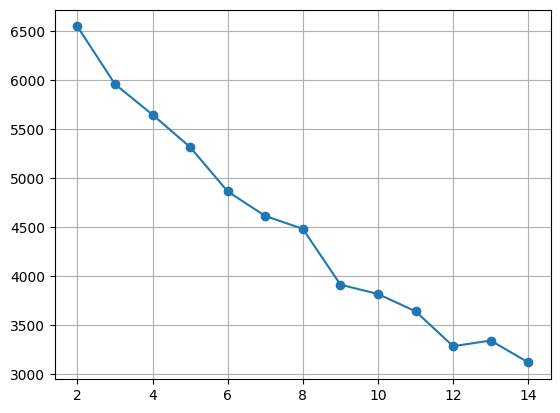

In [63]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

all_inertia = []

for k in range(2, 15):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(scaled)
    all_inertia.append(kmeans.inertia_)

plt.plot(range(2, 15), all_inertia, marker='o')
plt.grid()
plt.show()

В целом можем заметить что инерция проседает на k = 6 и k от 8 и до 10
Возьмем шесть чтобы Даня смог посетить больше городов и чтобы модель не переобучилась

In [64]:
N = 6

**Задание** Теперь когда мы определилиcь с количеством класетров давайте обучим нашу модель и получим предсказание.

In [65]:
kmeans = KMeans(n_clusters=N)
kmeans.fit(scaled)
tmp['cluster_kmeans'] = kmeans.predict(scaled)
tmp

,latitude,longitude,wind_degree,pressure_mb,precip_mm,humidity,cloud,visibility_km,uv_index,air_quality_Ozone,...,visibility_km_min,uv_index_max,uv_index_min,air_quality_max,air_quality_min,temperature_max,temperature_min,wind_max,wind_min,cluster_kmeans
0,-35.28,149.22,176.666667,1020.777778,0.148111,89.555556,38.544444,9.381111,1.0,31.495556,...,0.0,1.0,1.0,59.183333,35.066667,14.40,-4.30,41.20,3.65,1
1,-18.13,178.42,118.988764,1015.662921,0.446966,88.033708,61.247191,9.820225,1.0,34.617978,...,2.0,1.0,1.0,40.966667,25.266667,26.75,17.30,31.40,4.30,1
2,-0.88,169.53,92.321839,1009.241379,0.060690,72.011494,56.321839,9.919540,1.0,25.271264,...,5.0,1.0,1.0,46.416667,26.783333,31.85,29.35,37.10,4.65,1
3,7.10,171.38,87.123596,1010.224719,0.366067,80.044944,82.426966,18.232584,1.0,20.637079,...,5.0,1.0,1.0,46.200000,24.266667,32.60,26.95,43.25,6.05,1
4,6.92,158.15,99.808989,1011.224719,0.499326,86.460674,80.280899,19.550562,1.0,16.271910,...,5.0,1.0,1.0,45.050000,23.233333,32.80,24.95,35.30,3.75,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237,43.93,12.45,40.000000,1009.000000,0.000000,55.000000,0.000000,10.000000,8.0,128.800000,...,10.0,8.0,8.0,45.333333,45.333333,33.30,33.30,20.85,20.85,0
238,24.64,46.77,348.000000,997.000000,0.000000,7.000000,0.000000,10.000000,11.0,115.900000,...,10.0,11.0,11.0,46.833333,46.833333,46.50,46.50,26.35,26.35,3
239,37.70,65.37,332.000000,998.000000,0.000000,11.000000,2.000000,10.000000,9.0,105.900000,...,10.0,9.0,9.0,33.916667,33.916667,37.30,37.30,23.65,23.65,3
240,38.85,34.65,359.000000,1003.000000,0.000000,24.000000,4.000000,10.000000,7.0,85.100000,...,10.0,7.0,7.0,33.450000,33.450000,28.80,28.80,19.75,19.75,3


### Анализируем результаты кластеризации

Тепреь когда мы кластеризовали наши данные пора посмотреть на какие кластеры он их распределил. Эта информация поможет нам понять основные группы наших клиентов и волнуюзие их проблемы.

Для этого сравним среднее значение признака по каждому кластеру с средним значением среди всех наших клиентов.

In [66]:
tmp.groupby(['cluster_kmeans']).mean() - tmp.mean()

,air_quality,air_quality_Ozone,air_quality_Sulphur_dioxide,air_quality_max,air_quality_min,cloud,cloud_max,cloud_min,cluster_kmeans,humidity,...,uv_index,uv_index_max,uv_index_min,visibility_km,visibility_km_max,visibility_km_min,wind,wind_degree,wind_max,wind_min
cluster_kmeans,,,,,,,,,,,,,,,,,,,,,
0,-20.115374,4.107707,-1.477367,-58.840879,13.733377,-27.127550,-49.865811,0.160722,NaN,-13.829012,...,0.895138,0.198565,1.695955,0.228396,-0.359504,4.014876,0.520347,-16.469005,-23.557036,6.699326
1,2.878609,-32.043513,0.207699,-8.967773,9.829737,18.325723,9.922543,4.931159,NaN,22.408551,...,-3.625751,-3.995164,-2.300686,0.633558,1.555389,-2.085124,-2.179559,-13.663021,-14.342030,-1.670327
2,-29.194720,1.644155,-1.851470,-58.878942,-20.590518,-0.990901,9.724926,-8.276331,NaN,-0.687857,...,0.800073,1.233091,-0.027835,-0.112962,-0.287504,-0.380324,0.028805,-3.713397,16.040438,-1.896106
3,-10.911174,59.855622,1.104956,-42.479475,5.160378,-27.745129,-22.377324,-10.072831,NaN,-32.975212,...,3.016130,2.877841,2.786415,-0.033815,-0.172004,1.133626,4.899328,40.076672,-8.894124,2.443569
4,1091.357361,-56.989816,60.754062,2961.257941,287.696315,8.825597,5.028926,9.989669,NaN,19.127264,...,-3.787796,-4.340909,-2.369835,-1.085087,-0.359504,-2.310124,-8.367415,-25.547789,-28.367562,-2.528306
5,-8.002296,-30.996089,-1.908860,-105.757253,35.664371,42.034586,-2.571074,72.139669,NaN,18.281945,...,-1.864763,-2.990909,-0.019835,-0.971604,-1.559504,2.814876,-2.290458,15.932361,-32.354229,8.010028


In [67]:
tmp.mean()

latitude                         18.697064
longitude                        21.868417
wind_degree                     186.334306
pressure_mb                    1011.567621
precip_mm                         0.171317
humidity                         60.451388
cloud                            40.365414
visibility_km                     9.771604
uv_index                          5.464763
air_quality_Ozone                61.929422
air_quality_Sulphur_dioxide       5.508860
air_quality                      85.524518
temperature                      27.379515
wind                             17.803791
pressure_mb_max                1017.446281
pressure_mb_min                1005.161157
precip_mm_max                     2.474174
precip_mm_min                     0.030579
humidity_max                     83.590909
humidity_min                     41.508264
cloud_max                        84.971074
cloud_min                        10.260331
visibility_km_max                10.359504
visibility_

In [68]:
import folium
all_colors = ["cadetblue", "blue", "darkpurple", 'purple', 'lightgreen', 'red', 'orange', 'lightblue', 'darkred', 'darkgreen', 'lightred', 'gray', 'pink', 'darkblue', 'lightgray', 'beige', 'black', 'green', 'white']
data = tmp


map = folium.Map(location=[0, 0], zoom_start = 2)


for i in range(data.shape[0]):
    folium.Marker(location=[data.loc[i]["latitude"], data.loc[i]["longitude"]], popup = "Group " + str(i % N), icon=folium.Icon(color = all_colors[i % N])).add_to(map)

map.save("map.html")